In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
df = pd.read_csv(r"apple_data\Apple Stock Prices (1981 to 2023).csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,02/01/1981,0.154018,0.155134,0.154018,0.154018,0.119849,21660800
1,05/01/1981,0.151228,0.151228,0.150670,0.150670,0.117244,35728000
2,06/01/1981,0.144531,0.144531,0.143973,0.143973,0.112032,45158400
3,07/01/1981,0.138393,0.138393,0.137835,0.137835,0.107256,55686400
4,08/01/1981,0.135603,0.135603,0.135045,0.135045,0.105085,39827200


In [18]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 10608 entries, 0 to 10607
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10608 non-null  str    
 1   Open       10608 non-null  float64
 2   High       10608 non-null  float64
 3   Low        10608 non-null  float64
 4   Close      10608 non-null  float64
 5   Adj Close  10608 non-null  float64
 6   Volume     10608 non-null  int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 580.3 KB


Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

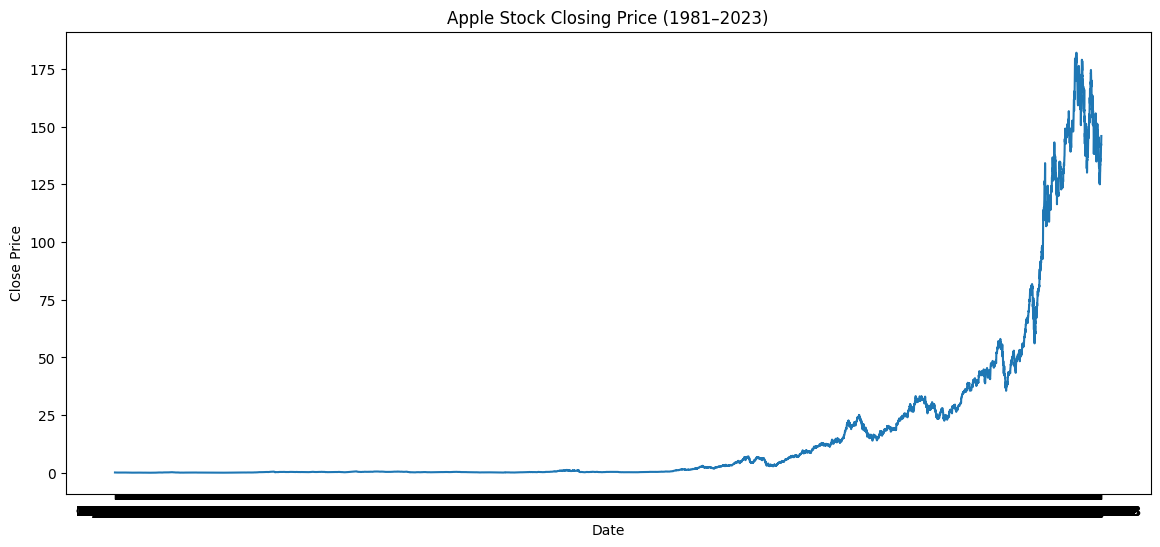

In [20]:
plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['Close'])
plt.title("Apple Stock Closing Price (1981–2023)")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

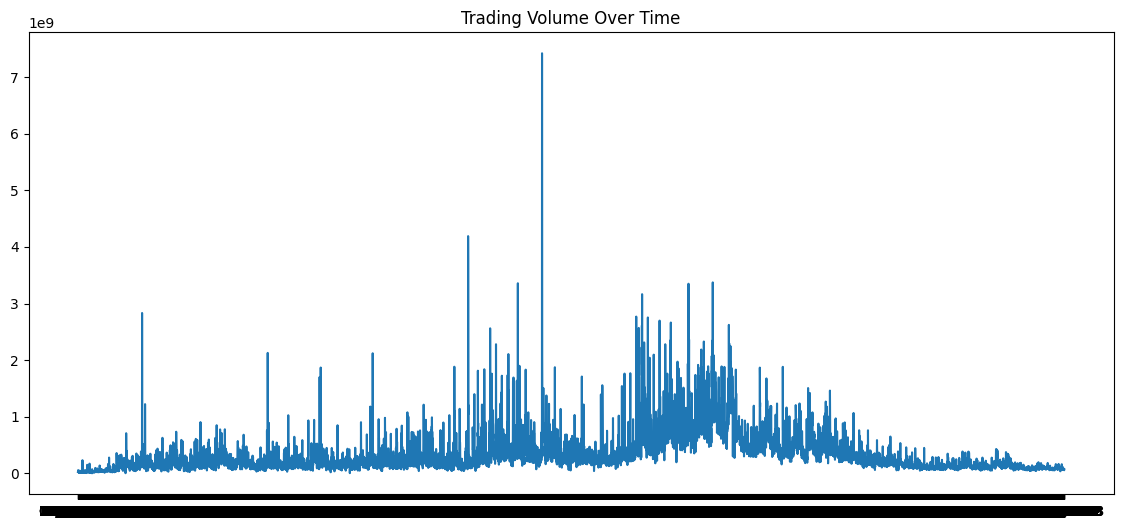

In [21]:
plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['Volume'])
plt.title("Trading Volume Over Time")
plt.show()

In [22]:
df[['Open','High','Low','Close','Volume']].describe()

,Open,High,Low,Close,Volume
count,10608.000000,10608.000000,10608.000000,10608.000000,1.060800e+04
mean,16.689173,16.879955,16.500822,16.697362,3.275098e+08
std,35.450519,35.882848,35.031289,35.473912,3.378203e+08
min,0.049665,0.049665,0.049107,0.049107,0.000000e+00
25%,0.287946,0.296875,0.282355,0.288923,1.213044e+08
50%,0.488839,0.495536,0.480446,0.487701,2.145976e+08
75%,16.320893,16.418483,16.151249,16.269554,4.066804e+08
max,182.630005,182.940002,179.119995,182.009995,7.421641e+09


In [23]:
df['Returns'] = df['Close'].pct_change()

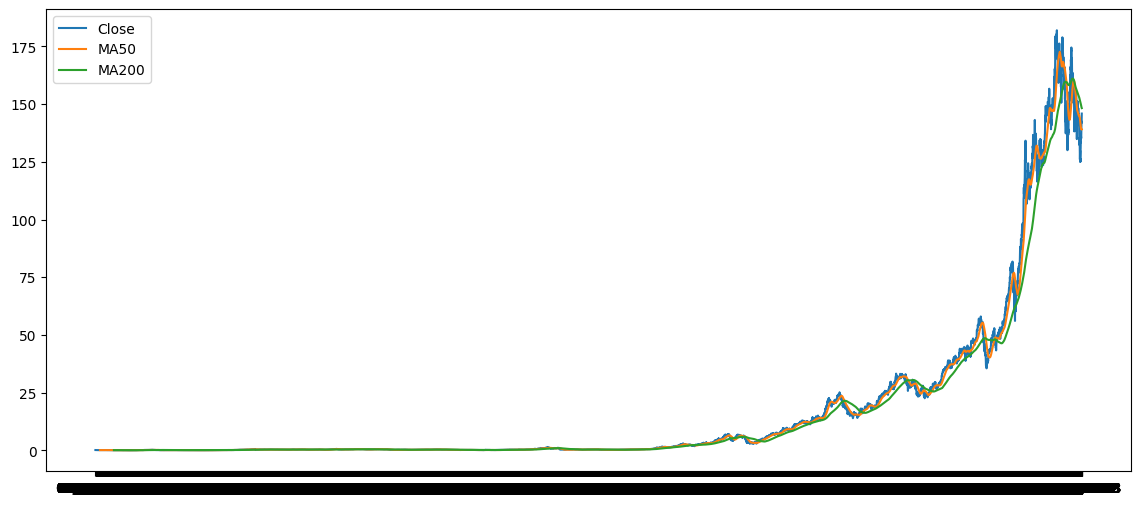

In [24]:
df['MA50'] = df['Close'].rolling(50).mean()
df['MA200'] = df['Close'].rolling(200).mean()
plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['Close'], label="Close")
plt.plot(df['Date'], df['MA50'], label="MA50")
plt.plot(df['Date'], df['MA200'], label="MA200")
plt.legend()
plt.show()

In [30]:
df['Date'].head()
df['Date'].dtype

<StringDtype(storage='python', na_value=nan)>

In [31]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [32]:
df['Date'].isnull().sum()

np.int64(6422)

In [33]:
df = df.dropna(subset=['Date'])

In [35]:
df['Year'] = df['Date'].dt.year
year_2010 = df[df['Year'] == 2010]['Close']
year_2020 = df[df['Year'] == 2020]['Close']

In [36]:
t_stat, p_value = stats.ttest_ind(year_2010.dropna(), year_2020.dropna())
print("T-stat:", t_stat)
print("P-value:", p_value)

T-stat: -40.16184892690798
P-value: 1.5581849845789009e-96


In [38]:
data = df['Returns'].dropna()
sample = data.sample(min(5000, len(data)))

In [39]:
data = df['Returns'].dropna()
sample = data.sample(min(3000, len(data)))

In [41]:
sample = df['Returns'].dropna().sample(3000)
stat, p = stats.shapiro(sample)
print("Shapiro p-value:", p)

Shapiro p-value: 1.0996414388388503e-32


In [42]:
np.corrcoef(df['Close'].dropna(), df['Volume'].dropna())

array([[ 1.        , -0.22030999],
       [-0.22030999,  1.        ]])

In [43]:
window = np.ones(20) / 20
df['MA20_conv'] = np.convolve(df['Close'], window, mode='same')

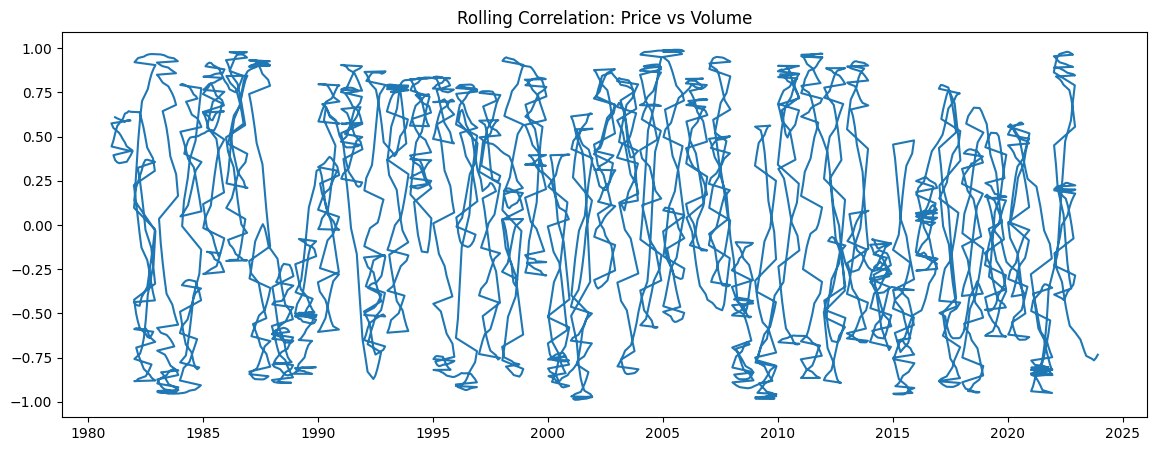

In [45]:
df['MA_Close'] = df['Close'].rolling(20).mean()
df['MA_Volume'] = df['Volume'].rolling(20).mean()
corr = df['MA_Close'].rolling(50).corr(df['MA_Volume'])
plt.figure(figsize=(14,5))
plt.plot(df['Date'], corr)
plt.title("Rolling Correlation: Price vs Volume")
plt.show()

## 6. Summary & Insights

### Key Observations
- Apple shows a strong long-term upward trend in stock price.
- Significant volatility is observed during certain market periods (crises and bull runs).
- Trading volume tends to increase during periods of high price fluctuation.

###  Statistical Findings
- Daily returns are not normally distributed.
- T-tests show significant differences in average stock prices between selected years.
- Correlations vary depending on market periods and time windows.

## Conclusion

This project provided a complete statistical analysis of Apple stock data using Python, Pandas, NumPy, and SciPy.
The analysis helped identify long-term trends, test statistical hypotheses, and visualize financial behavior over time.
It also highlighted the importance of time series handling, statistical testing, and data visualization in financial analysis.